## Model Selection

Before we move on we would like to choose the best possible model for each of the two cases: daily forecast and hourly forecast. It seems that for the daily forecast in the long term you choose linear_order2 in the short to medium term potentially hybrid_order2. For the hourly forecast it seems that just using XGBoost is the best possible model.

The main question is that in the daily forecast if we were to optimise the hyperparameters of the XGBoost model within the hybrid model would it make hybrid_order2 better than linear_order2 in both the short and long term. It would also be nice to do hyperparamter optimisation for the hourly forecast as well just to see whether we can improve the predictions or not. 

Finally it would be good to look at SHAP values to see if we can drop any of the features, particualarly some of the lags as they can make the models computationally expensive.

For our own use (maybe delete later): http://kaggle.com/code/prashant111/a-guide-on-xgboost-hyperparameters-tuning

https://hyperopt.github.io/hyperopt/?source=post_page

https://github.com/hyperopt/hyperopt/wiki/FMin

In [55]:
from hyperopt import hp, fmin, tpe, hp, STATUS_OK, Trials
import xgboost as xgb
from xgboost.callback import EarlyStopping
import pickle
import pandas as pd
from jfk_taxis import load_design, load_models, load_lags, run_forecasts
from sklearn.metrics import mean_absolute_error

In [56]:
# First reload the significant lags
daily_lags = load_lags("daily", "eda")

hourly_lags = load_lags("hourly", "eda")

In [57]:
# Get both the full daily and hourly time series
dir_path = "../data/processed/"
df_daily = pd.read_csv(f"{dir_path}ts_daily2011-2025.csv")
df_hourly = pd.read_csv(f"{dir_path}ts_hour2011-2025.csv")

# Convert dates to datetime objects
df_daily["pickup_date"] = pd.to_datetime(df_daily["pickup_date"])
df_hourly["dt"] = pd.to_datetime(df_hourly["dt"])


In [58]:
# To pass the time series through our helper functions they need to be a pandas series indexed by a datetime object:
ts_hourly = df_hourly["trips"]
ts_hourly.index = df_hourly["dt"]

ts_daily = df_daily["trips"]
ts_daily.index = df_daily["pickup_date"]

In [59]:
# We now need to split into test and train data, we will train on the pre 2024 data and test on 2024 onwards, approx a 90:10 split
ts_daily_train = ts_daily[:"2023-12-31"]
ts_daily_test = ts_daily["2024-01-01":]

ts_hourly_train = ts_hourly[:"2023-12-31"]
ts_hourly_test = ts_hourly["2024-01-01":]

In [2]:
# First we need to load the design and target matricies
# Suppose we are trying to optimise for the daily time series then we can load the non_linear_design matrix from the sig "5_order_linear_daily"

linear_design_loaded, non_linear_design_loaded = load_design("5_order_linear_daily")


In [51]:
# Get design and target
X = non_linear_design_loaded["base_non_linear"][0]
y = non_linear_design_loaded["base_non_linear"][1]
dp = non_linear_design_loaded["base_non_linear"][2]

In [12]:
# Now previously we trained on the whole of X, we are now going to create a validation set that we can evaluate on. 
# For this example we will just use the year 2023
X_train = X[:"2022-12-31"]
y_train = y[:"2022-12-31"]

X_test = X["2023-01-01":]
y_test = y["2023-01-01":]

In [40]:
# Define search space
space = {'max_depth': hp.quniform('max_depth', 3, 18, 1),
          'gamma': hp.uniform ('gamma', 1, 9),
          'reg_alpha': hp.quniform('reg_alpha', 40, 180, 1),
          'reg_lambda': hp.uniform('reg_lambda', 0, 1),
          'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1),
          'min_child_weight': hp.quniform('min_child_weight', 0, 10, 1),
          'n_estimators': hp.quniform('n_estimators', 100, 500, 100),
          'seed': 37}

In [41]:
print(x)

0 float
1   hyperopt_param
2     Literal{n_estimators}
3     quniform
4       Literal{100}
5       Literal{500}
6       Literal{100}


In [44]:
# Define objective function

def objective(space):
    clf = xgb.XGBRegressor(
        n_estimators = int(space['n_estimators']),
        max_depth = int(space['max_depth']),
        gamma = space['gamma'],
        reg_alpha = space['reg_alpha'],
        reg_lambda = space['reg_lambda'],
        colsample_bytree = int(space['colsample_bytree']),
        min_child_weight = int(space['min_child_weight']),
        eval_metric = "mae",
        early_stopping_rounds = 10)

    evaluation = [(X_train, y_train), (X_test, y_test)]

    clf.fit(X_train, y_train,
            eval_set = evaluation,
            verbose = False)

    pred = clf.predict(X_test)
    mae = mean_absolute_error(pred, y_test)
    print("MAE:", mae)
    return {'loss': mae, 'status': STATUS_OK}

In [45]:
# Optimisation algorithm
trials = Trials()

best_hyperparams = fmin(fn = objective,
                        space = space,
                        algo = tpe.suggest,
                        max_evals = 100,
                        trials = trials)

MAE:                                                                      
816.288330078125                                                          
MAE:                                                                      
788.822265625                                                             
MAE:                                                                      
772.590576171875                                                          
MAE:                                                                      
790.4063110351562                                                         
MAE:                                                                      
783.205322265625                                                          
MAE:                                                                      
822.0205688476562                                                         
MAE:                                                                      
814.55419921875          

In [46]:
print("The best hyperparamters are: ", "\n")
print(best_hyperparams)

The best hyperparamters are:  

{'colsample_bytree': np.float64(0.7479461289635994), 'gamma': np.float64(2.5139188815764437), 'max_depth': np.float64(4.0), 'min_child_weight': np.float64(5.0), 'n_estimators': np.float64(200.0), 'reg_alpha': np.float64(135.0), 'reg_lambda': np.float64(0.8138180672362536)}


In [63]:
# It would now be interesting to use this hyperparams and use them on the forecasts from the previous notebook to see how they compare

# Load the previous non linear model
linear_models_loaded, non_linear_models_loaded = load_models("5_order_linear_daily")

# Now create our new non linear model trained on the full training data set
new_non_linear = xgb.XGBRegressor(
        n_estimators = int(best_hyperparams['n_estimators']),
        max_depth = int(best_hyperparams['max_depth']),
        gamma = best_hyperparams['gamma'],
        reg_alpha = best_hyperparams['reg_alpha'],
        reg_lambda = best_hyperparams['reg_lambda'],
        colsample_bytree = int(best_hyperparams['colsample_bytree']),
        min_child_weight = int(best_hyperparams['min_child_weight']),
        eval_metric = "mae")


new_non_linear.fit(X, y,
    verbose = False)

non_linear_models_loaded["new_non_linear"] = (new_non_linear, dp, None)

In [64]:
# Steps for the forecast
steps = [1, 2, 3, 7, 14, 28, 30, 60, 180, 365, 500, 546]


MAE Non Linear: 202.46 for step = 1, model = base_non_linear
MAE Non Linear: 382.17 for step = 1, model = new_non_linear


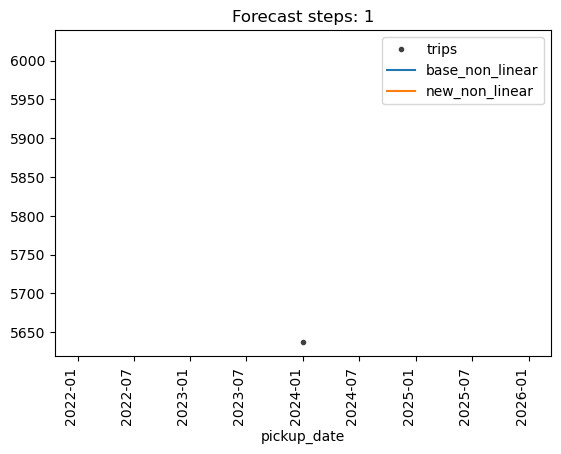

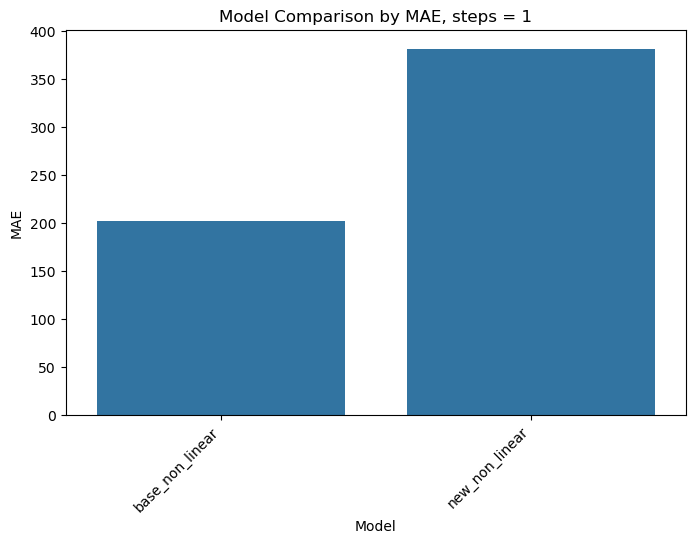

MAE Non Linear: 434.77 for step = 2, model = base_non_linear
MAE Non Linear: 910.96 for step = 2, model = new_non_linear


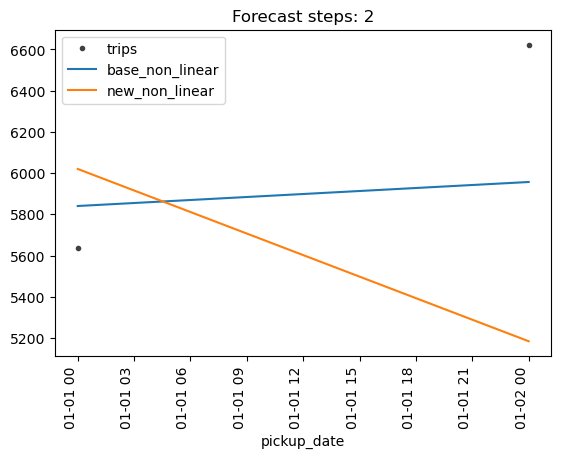

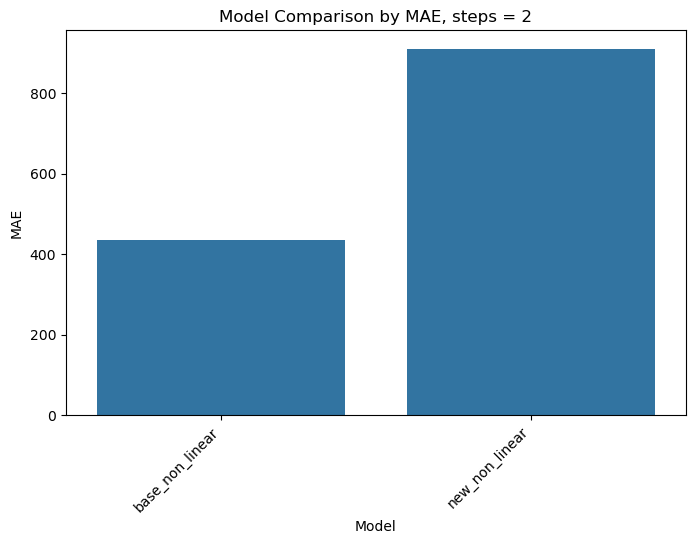

MAE Non Linear: 366.55 for step = 3, model = base_non_linear
MAE Non Linear: 1012.46 for step = 3, model = new_non_linear


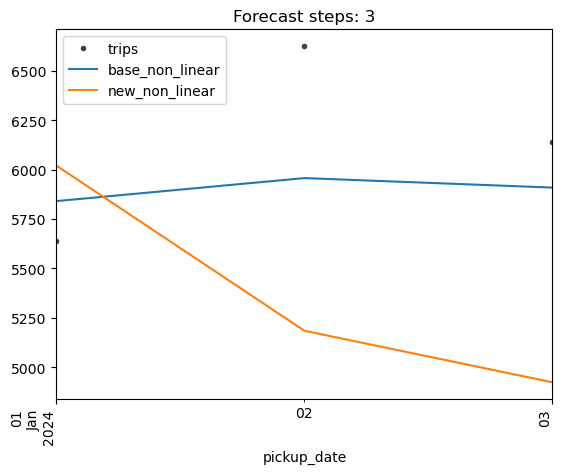

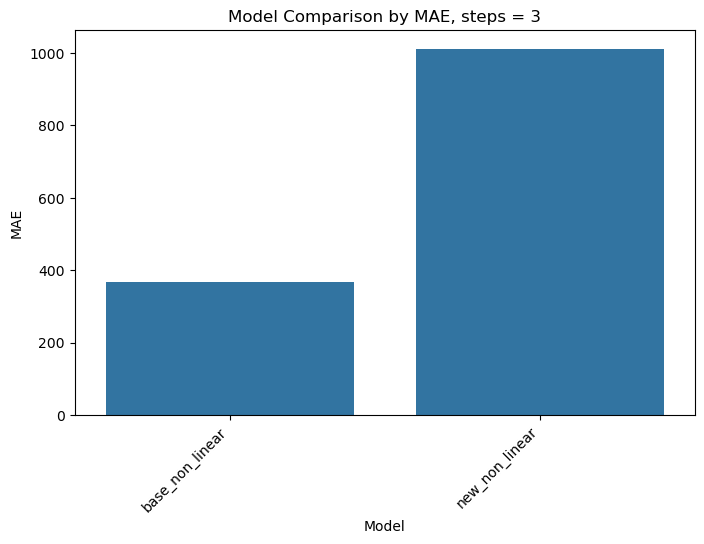

MAE Non Linear: 401.43 for step = 7, model = base_non_linear
MAE Non Linear: 635.61 for step = 7, model = new_non_linear


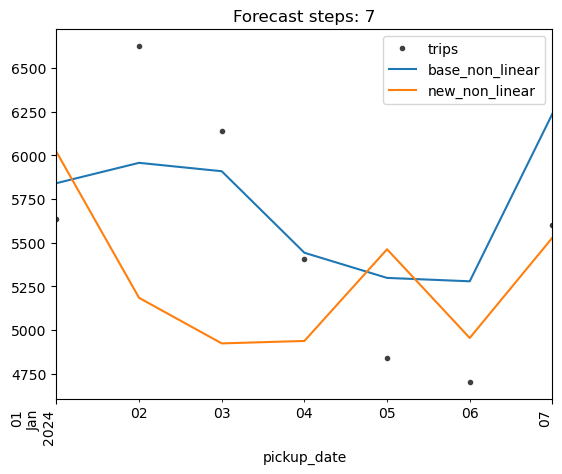

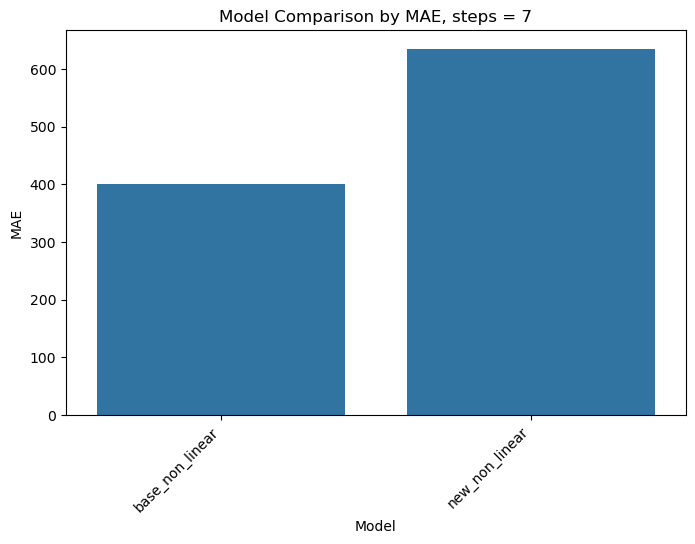

MAE Non Linear: 499.66 for step = 14, model = base_non_linear
MAE Non Linear: 674.18 for step = 14, model = new_non_linear


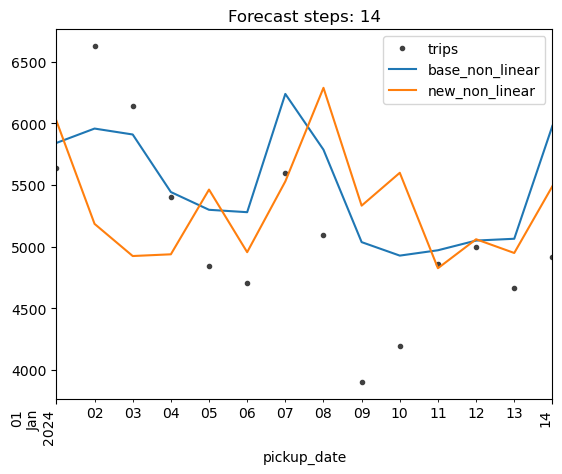

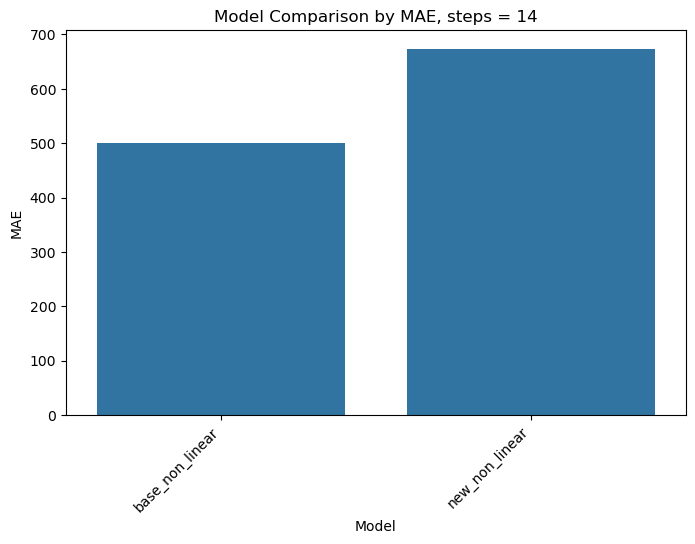

MAE Non Linear: 559.00 for step = 28, model = base_non_linear
MAE Non Linear: 872.86 for step = 28, model = new_non_linear


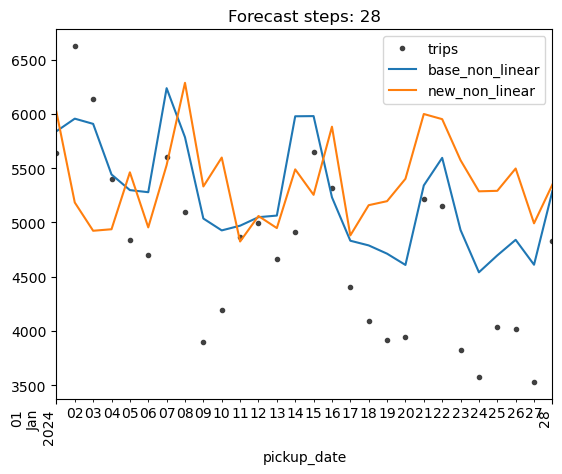

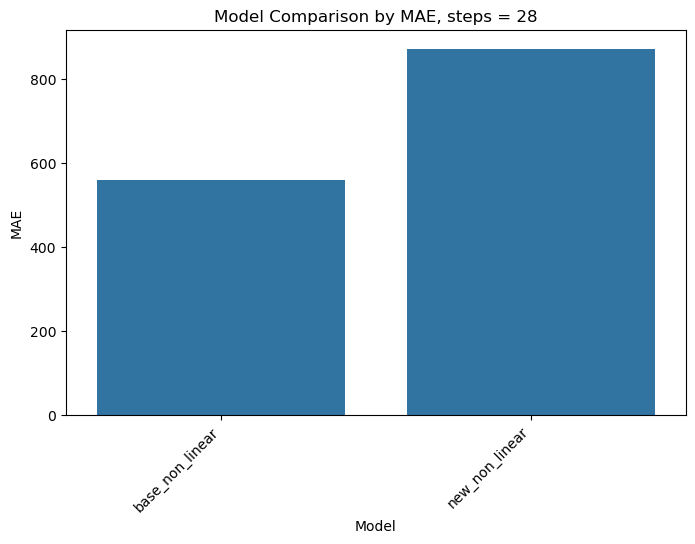

MAE Non Linear: 578.59 for step = 30, model = base_non_linear
MAE Non Linear: 890.30 for step = 30, model = new_non_linear


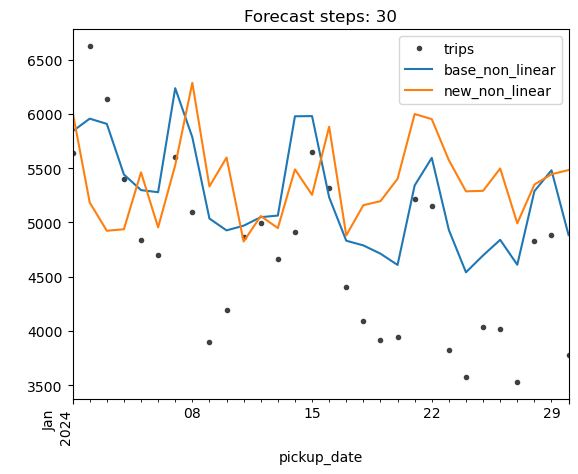

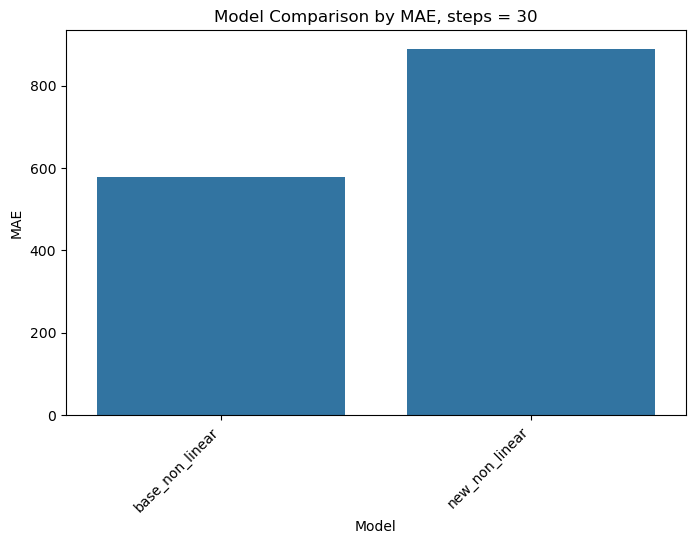

MAE Non Linear: 649.78 for step = 60, model = base_non_linear
MAE Non Linear: 816.73 for step = 60, model = new_non_linear


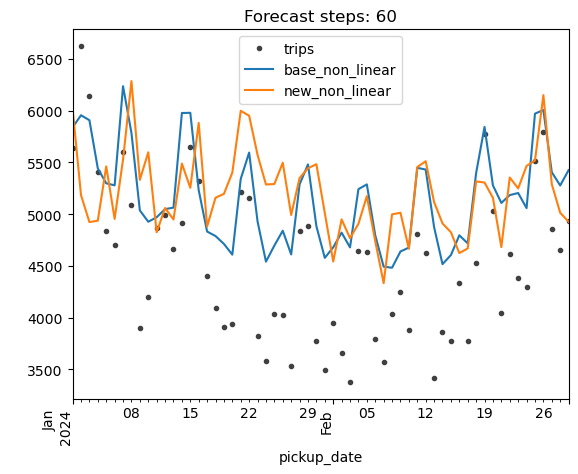

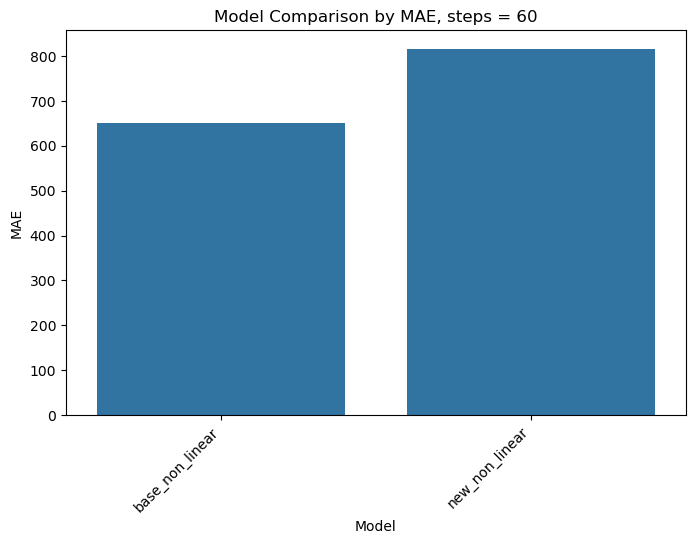

MAE Non Linear: 596.61 for step = 180, model = base_non_linear
MAE Non Linear: 619.65 for step = 180, model = new_non_linear


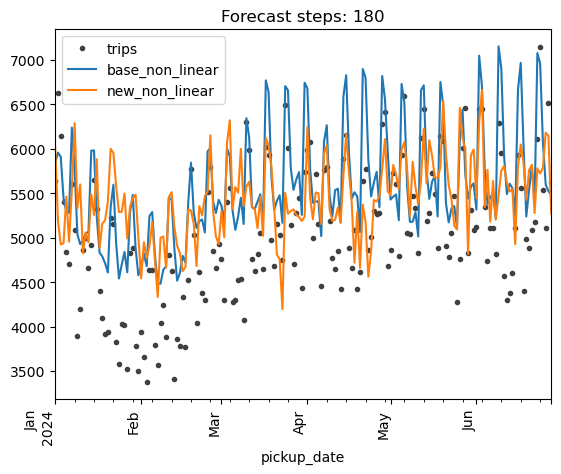

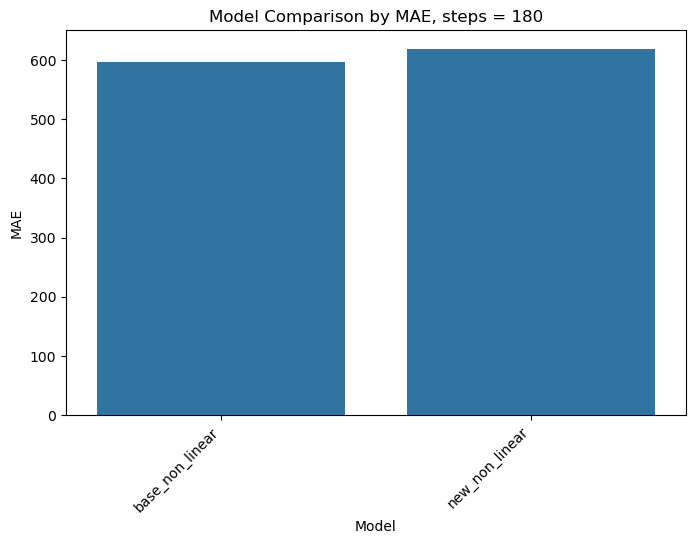

MAE Non Linear: 558.75 for step = 365, model = base_non_linear
MAE Non Linear: 661.47 for step = 365, model = new_non_linear


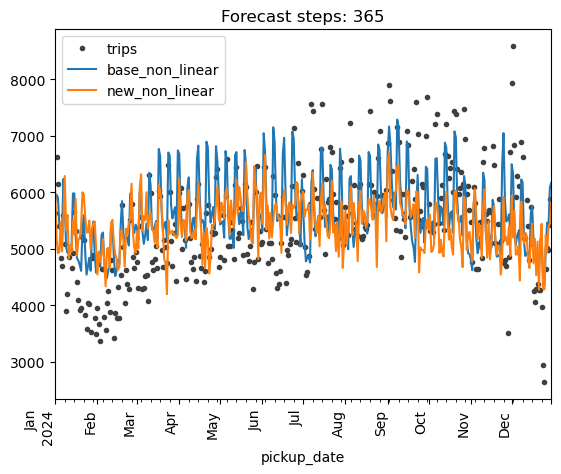

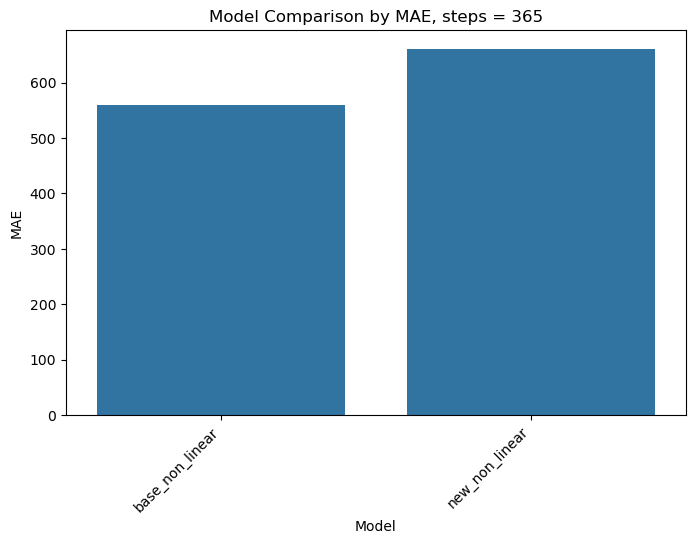

MAE Non Linear: 565.09 for step = 500, model = base_non_linear
MAE Non Linear: 658.40 for step = 500, model = new_non_linear


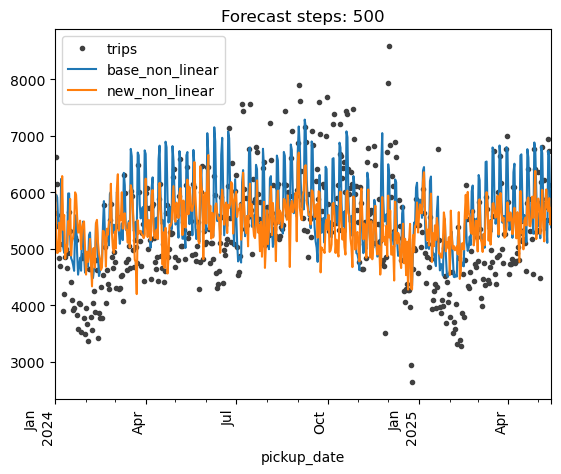

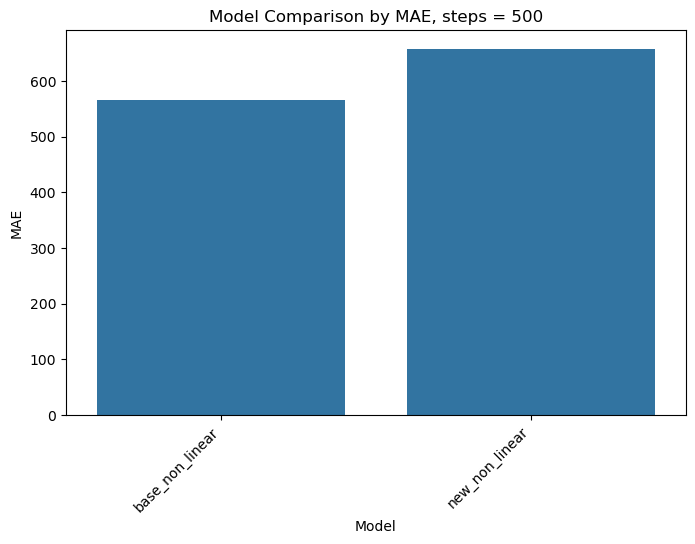

MAE Non Linear: 566.62 for step = 546, model = base_non_linear
MAE Non Linear: 677.66 for step = 546, model = new_non_linear


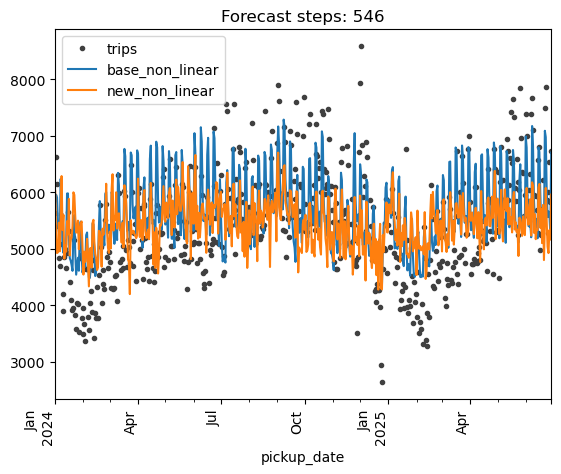

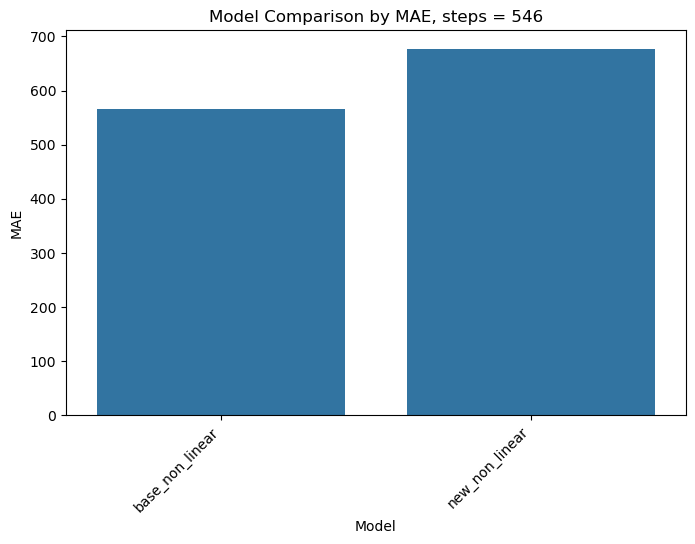

0

In [65]:
# Run forecasts
run_forecasts(steps, daily_lags, {}, non_linear_models_loaded, False, "D", ts_daily_train, ts_daily_test)